<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/euler-and-solve-ivp-Cooper-9/blob/main/Euler_Solve_ivp_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Problems 1, 2, and 3 are all listed below. I had trouble renaming x and v as theta and angular velocity, so I left them alone in the problem 1 code. Also I'm not entirely sure how to answer part 4 of question 1, but I had to go with the implicit angular velocity to make the code work.

## Pseudocode for solving initial value problems/ temporal evolution of systems

For our custom Euler code:
1. **Import modules:** import 'math' for simple functions and constants; import 'matplotlib.pyplot' for plotting.
2. **Define the differential equation as a first-order system:** made a custom function from $\ddot{\theta} + \omega_0^2 sin(\theta)=0$ to give $\dot{\theta} = \Omega$ and $\dot{\Omega} = - \omega_0^2 sin(\theta)$.
3. **Assign variables and time span:** define `omega_0`, the initial conditions (`theta_0`: initial angle; and `ang_vel_0`: initial angular velocity), and the time span.
4. **Solve differential equaiton numerically:** call our custom euler solver.
5. **Plot results and test output:** plot the temporal evolution of `theta` (`theta` vs. `t`), and the phase portrait (`ang_vel` vs. `theta`). Define and compare with an analytic solution to the harmonic oscillator/small-angle approximation.

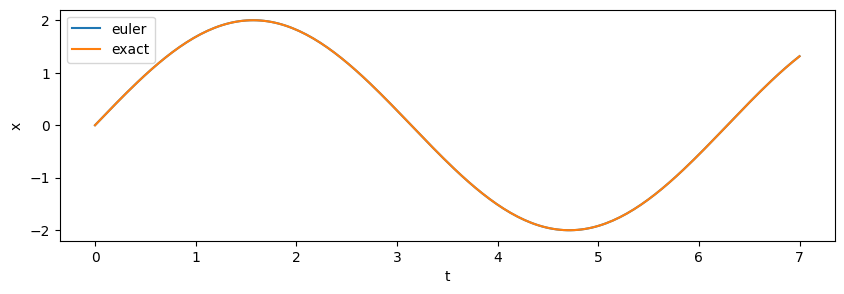

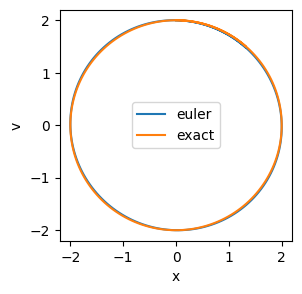

In [20]:
# PROBLEM 1
# Code cell for (theta_0 = 0, ang_vel = 2)

import math

# define our test euler method for a simple harmonic oscillator
def euler_sho(omega_0, x_0, v_0, t_0, t_f, n_steps):
  """
  This function calculates the solution to x'' = - omega_0 ^2 x with Euler's method.
  """
  dt = (t_f - t_0) / n_steps # calculate dt
  x = [x_0] # initialized x list
  v = [v_0] # initialized v list
  t = [t_0] # initialized t list
  for _ in range(n_steps):
    x_new = x[-1] + v[-1] * dt # update x
    v_new = v[-1] - omega_0 ** 2 * x_new * dt # update v : using an implicit form
    t_new = t[-1] + dt # update t
    x.append(x_new) # append x
    v.append(v_new) # append v
    t.append(t_new) # append t
  return t, x, v


# assign variables and call function
omega_0 = 1
x_0     = 0
v_0     = 2
t_0     = 0
t_f     = 7
n_steps = 200

t, x, v = euler_sho(omega_0, x_0, v_0, t_0, t_f, n_steps)

# get the exact values
x_exact_sho = [x_0 * math.cos(omega_0 * (t[i] - t_0)) + (v_0 / omega_0) * math.sin(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension
v_exact_sho = [- x_0 * omega_0 * math.sin(omega_0 * (t[i] - t_0)) + v_0 * math.cos(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension

# plot with matplotlib
plt.figure(figsize=(10,3))
plt.plot(t, x, label='euler')
plt.plot(t, x_exact_sho,label='exact')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

# plot a phase portrait wiht matplotlib
plt.figure(figsize=(3,3))
plt.plot(x, v, label='euler')
plt.plot(x_exact_sho, v_exact_sho,label='exact')
plt.xlabel('x')
plt.ylabel('v')
plt.legend()
plt.show()

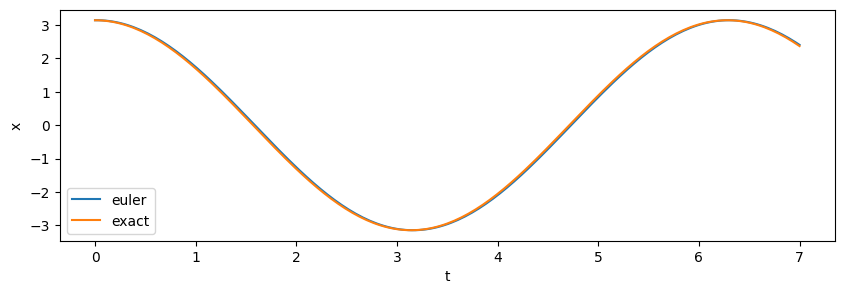

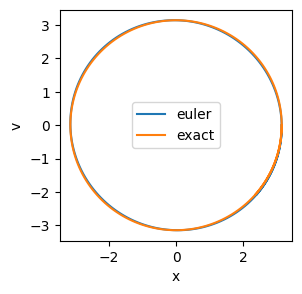

In [21]:
# PROBLEM 1
# Code cell for (theta_0 = math.pi, ang_vel = 0)


import math

# define our test euler method for a simple harmonic oscillator
def euler_sho(omega_0, x_0, v_0, t_0, t_f, n_steps):
  """
  This function calculates the solution to x'' = - omega_0 ^2 x with Euler's method.
  """
  dt = (t_f - t_0) / n_steps # calculate dt
  x = [x_0] # initialized x list
  v = [v_0] # initialized v list
  t = [t_0] # initialized t list
  for _ in range(n_steps):
    x_new = x[-1] + v[-1] * dt # update x
    v_new = v[-1] - omega_0 ** 2 * x_new * dt # update v : using an implicit form
    t_new = t[-1] + dt # update t
    x.append(x_new) # append x
    v.append(v_new) # append v
    t.append(t_new) # append t
  return t, x, v


# assign variables and call function
omega_0 = 1
x_0     = math.pi
v_0     = 0
t_0     = 0
t_f     = 7
n_steps = 200

t, x, v = euler_sho(omega_0, x_0, v_0, t_0, t_f, n_steps)

# get the exact values
x_exact_sho = [x_0 * math.cos(omega_0 * (t[i] - t_0)) + (v_0 / omega_0) * math.sin(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension
v_exact_sho = [- x_0 * omega_0 * math.sin(omega_0 * (t[i] - t_0)) + v_0 * math.cos(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension

# plot with matplotlib
plt.figure(figsize=(10,3))
plt.plot(t, x, label='euler')
plt.plot(t, x_exact_sho,label='exact')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

# plot a phase portrait wiht matplotlib
plt.figure(figsize=(3,3))
plt.plot(x, v, label='euler')
plt.plot(x_exact_sho, v_exact_sho,label='exact')
plt.xlabel('x')
plt.ylabel('v')
plt.legend()
plt.show()

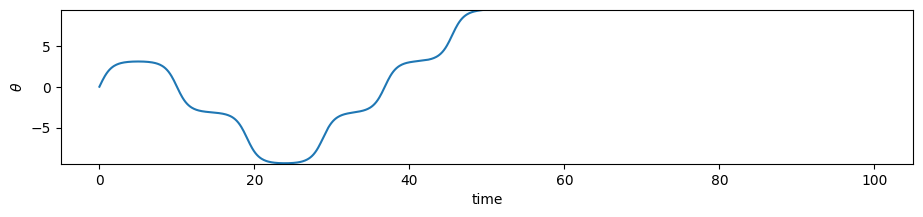

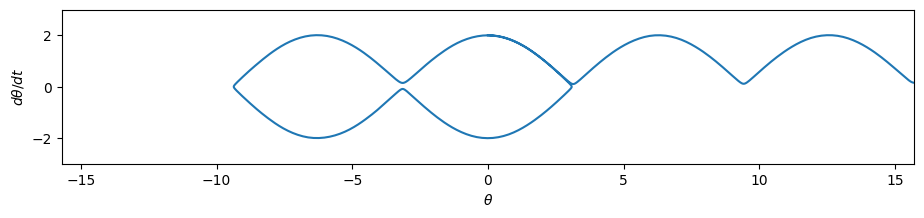

In [17]:
# PROBLEM 2
# Code cell for (theta_0 = 0, ang_vel = 2)


# define our differential equation

def rigid_pendulum_ode(t, y, omega_0=1):

 """

 Returns the time derivative of y=[theta, ang_vel] (the angle and angular velocity).

 """

 theta, ang_vel = y # unpacks y=[theta, ang_vel]
 dtheta_dt = ang_vel # define first derivative
 d2theta_dt2 = - omega_0 ** 2 * np.sin(theta) # define second derivative
 dy_dt = [dtheta_dt, d2theta_dt2] # define derivative of state variable
 return dy_dt


# Define the initial conditions, input parameters, and the time span
# initial conditions
theta_0 = 0 # initial angle
ang_vel_0 = 2 # initial angular velocity
y_0 = [theta_0, ang_vel_0] # initial state


# input parameters
omega_0 = 1 # natural frequency


# time span
t_initial = 0 # initial time
t_final = 100 # final time
t_span = [t_initial, t_final] # time span


# solve differential equation
solution = solve_ivp(rigid_pendulum_ode,
 t_span, # time span to solve over
 y_0, # initial conditions
 args=(omega_0,), # passes `omega_0` to `rigid_pendulum_ode`
 dense_output=True # returns an interpolated solution
)



# create list for plotting our solution
n_steps = 1000 # number of time steps
t_plot = np.linspace(t_initial, t_final, n_steps) # list of times for plotting
theta_plot = solution.sol(t_plot)[0] # evaluate the interpolant on a mesh for plotting
ang_vel_plot = solution.sol(t_plot)[1] # evaluate the interpolant on a mesh for plotting


# plot the temporal evolution
plt.figure(figsize=(11,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.ylim(- 3 * np.pi, 3 * np.pi)
plt.show()


# plot the phase portrait
plt.figure(figsize=(11,2))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta/dt$")
plt.xlim(- 5 * np.pi, 5 * np.pi)
plt.ylim(-3, 3)
plt.show()

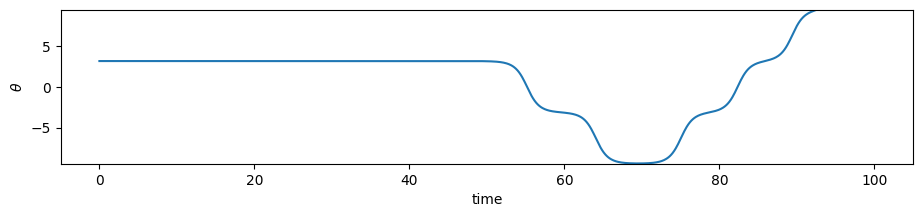

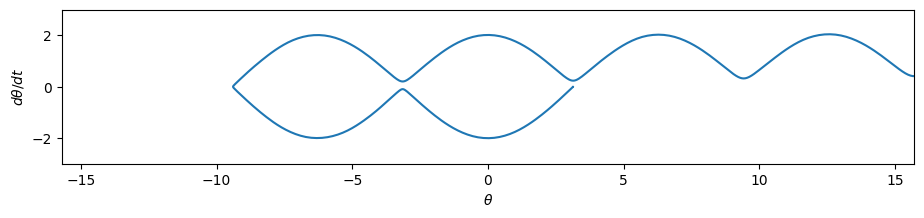

In [16]:
# PROBLEM 2
# code cell for (ang_vel = 0, and theta_0 = math.pi)




# import packages
import math
import numpy as np # imports the `numpy` package and gives it an alias/name `np`
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # imports the `solve_ivp` function from the `integrate` submodule of the `scipy` module


# define our differential equation
def rigid_pendulum_ode(t, y, omega_0=1):

 """

 Returns the time derivative of y=[theta, ang_vel] (the angle and angular velocity).

 """

 theta, ang_vel = y # unpacks y=[theta, ang_vel]
 dtheta_dt = ang_vel # define first derivative
 d2theta_dt2 = - omega_0 ** 2 * np.sin(theta) # define second derivative
 dy_dt = [dtheta_dt, d2theta_dt2] # define derivative of state variable
 return dy_dt



# Define the initial conditions, input parameters, and the time span
# initial conditions
theta_0 = np.pi # initial angle
ang_vel_0 = 0 # initial angular velocity
y_0 = [theta_0, ang_vel_0] # initial state



# input parameters
omega_0 = 1 # natural frequency


# time span
t_initial = 0 # initial time
t_final = 100 # final time
t_span = [t_initial, t_final] # time span


# solve differential equation
solution = solve_ivp(rigid_pendulum_ode,
 t_span, # time span to solve over
 y_0, # initial conditions
 args=(omega_0,), # passes `omega_0` to `rigid_pendulum_ode`
 dense_output=True # returns an interpolated solution
 )


# create list for plotting our solution
n_steps = 1000 # number of time steps
t_plot = np.linspace(t_initial, t_final, n_steps) # list of times for plotting
theta_plot = solution.sol(t_plot)[0] # evaluate the interpolant on a mesh for plotting
ang_vel_plot = solution.sol(t_plot)[1] # evaluate the interpolant on a mesh for plotting


# plot the temporal evolution
plt.figure(figsize=(11,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.ylim(- 3 * np.pi, 3 * np.pi)
plt.show()


# plot the phase portrait
plt.figure(figsize=(11,2))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta/dt$")
plt.xlim(- 5 * np.pi, 5 * np.pi)
plt.ylim(-3, 3)
plt.show()

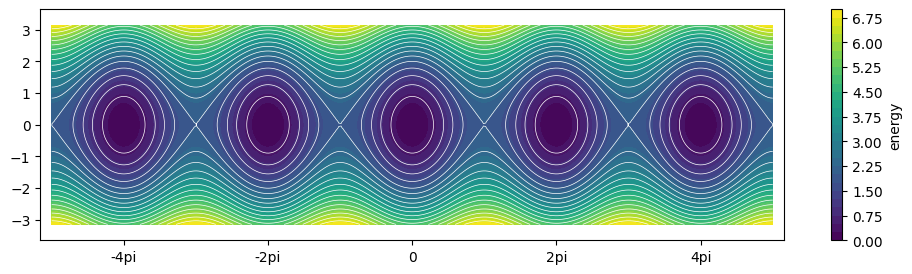

In [42]:
# PROBLEM 3
# Debugged code

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def rigid_pendulum_energy(theta, ang_vel, omega_0=1, moment_of_inertia=1):
  energy = 0.5 * moment_of_inertia * ang_vel ** 2 + moment_of_inertia * omega_0 ** 2 * (1-np.cos(theta))
  return energy

theta_list = np.linspace(-5 * np.pi, 5 * np.pi, 300)
ang_vel_list = np.linspace(- np.pi,  np.pi, 100)
theta_mesh, ang_vel_mesh = np.meshgrid(theta_list, ang_vel_list)
energy_mesh = rigid_pendulum_energy(theta_mesh, ang_vel_mesh)
low_levels = np.linspace(0, 2, 5, endpoint=False)
high_levels = np.linspace(2, energy_mesh.max(), 15)
levels = np.concatenate((low_levels, high_levels))

x_lim = [-5 * np.pi - 0.5, 5 * np.pi + 0.5]
y_lim = [- np.pi - 0.5, np.pi + 0.5]
x_ticks = np.pi * np.array([-4, -2, 0, 2, 4])
x_ticks_labels = ['-4pi', '-2pi', '0', '2pi', '4pi']
plt.figure(figsize=(12, 3))
contours = plt.contourf(theta_mesh, ang_vel_mesh, energy_mesh, levels=30, cmap='viridis')
plt.contour(theta_mesh, ang_vel_mesh, energy_mesh, levels=levels, colors='white', linewidths=0.5)
# plt.plot(theta_plot[0], ang_vel_plot[1], label='rigid pendulum', color='red', linewidth=0.5)
plt.colorbar(contours, label='energy')
plt.xlabel('')
plt.ylabel('')
plt.xticks(x_ticks, x_ticks_labels)
plt.yticks(range(-3,4,1))
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

This energy contour graphs looks similar to the pattern made by the phase portrait graphs from problem 2.